# Systems of SDE

$$
    dX^1(t) = X^1(t)X^2(t)dW^1(t)
$$

$$
    dX^2(t) = -(X^2(t) - X^3(t))dt + 0.3X^2(t)dW^2(t)
$$

$$
    dX^3(t) = \frac{1}{\alpha} (X^2(t) - X^3(t))dt
$$

# Milstein Scheme

$$
    X_{n+1}^1 = X_n^1 + X_n^1 X_n^2 \triangle W_n^1 + \frac{1}{2} X_n^1 (X_n^2)^2 \left[ (\triangle W_n^1)^2 - \triangle t \right]
                + 0.3X_n^1 X_n^2 \int_{t_n}^{t_{n+1}} \int_{t_n}^t dW^2(s) dW^1(t)
$$

$$
    X_{n+1}^2 = X_n^2 - \triangle t (X_n^2 - X_n^3) + 0.3X_n^2 \triangle W_n^2 + 0.045X_n^2 \left[ (\triangle W_n^2)^2 - \triangle t \right]
$$

$$
    X_{n+1}^3 = X_n^3 + \frac{\triangle t}{\alpha} (X_n^2 - X_n^3)
$$

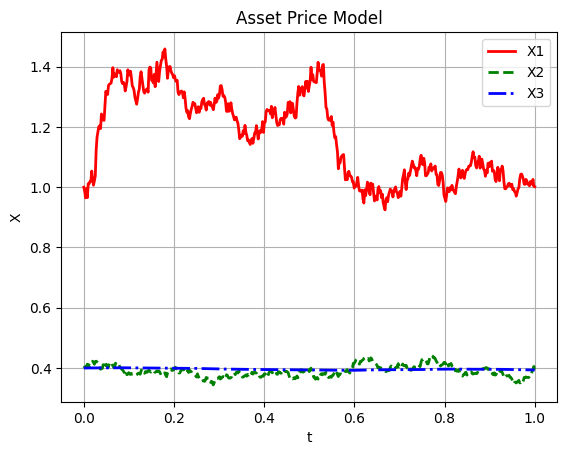

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Dt = 2**(-9)
dt = Dt**2

T = 1

L = int(T/Dt)
K = int(Dt/dt)

X1 = np.zeros(L+1)
X2 = np.zeros(L+1)
X3 = np.zeros(L+1)

X1[0] = 1.
X2[0] = 0.4
X3[0] = 0.4

for i in range(1, L+1):
    Y1 = 0.
    Y2 = 0.

    W1 = 0.
    W2 = 0.

    for k in range(K):
        dW1 = np.sqrt(dt)*np.random.randn()
        dW2 = np.sqrt(dt)*np.random.randn()

        Y1 += Y2*dW1
        Y2 += dW2

        W1 += dW1
        W2 += dW2

    X1[i] = X1[i-1] + X1[i-1]*X2[i-1]*W1 + X1[i-1]*X2[i-1]**2*0.5*(W1**2 - Dt) + 0.3*X1[i-1]*X2[i-1]*Y1
    X2[i] = X2[i-1] - (X2[i-1] - X3[i-1])*Dt + 0.3*X2[i-1]*W2 + 0.09*X2[i-1]*0.5*(W2**2 - Dt)
    X3[i] = X3[i-1] + (X2[i-1] - X3[i-1])*Dt

t = np.linspace(0, T, L+1)

plt.plot(t, X1, 'r-', linewidth=2, label='X1')
plt.plot(t, X2, 'g--', linewidth=2, label='X2')
plt.plot(t, X3, 'b-.', linewidth=2, label='X3')

plt.grid(True)
plt.title('Asset Price Model')
plt.xlabel("t")
plt.ylabel("X")
plt.legend()
plt.show()